# 영화 흥행 예측 - Modeling

**팀: 9조 | 모델링 및 평가 | Data Science Term Project 2026**


## 목차
1. 환경 설정 및 데이터 로드

2. Classification — `Hit` 예측 (8개 모델)

3. Regression — `Rating` 예측 (7개 모델)

4. Best-5 자동 탐색 함수 (오픈소스 기여)

5. Classification - Best-5 자동 탐색 함수

6. Regression - Best-5 자동 탐색 함수

7. 최종 결과 시각화 및 분석



## 모델링 전략
- **Classification 타겟**: `Hit` (이진, 클래스 불균형 10.3% : 89.7%) → 평가 지표는 F1, ROC-AUC 중심
- **Regression 타겟**: `Rating` (연속, 4.6~9.3)
- **Leakage 방지**: Hit이 Rating+Votes로 정의되므로, Regression의 X에서는 Hit을 제외하고 Classification의 X에서는 Rating을 제외함
- **CV**: StratifiedKFold (Classification), KFold (Regression), k=5

## 1. 환경 설정 및 데이터 로드

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, KFold,
    cross_val_score, cross_validate, GridSearchCV
)

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

# 시각화 설정
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
print('✅ Libraries loaded')

✅ Libraries loaded


In [ ]:
# 전처리 완료된 데이터 로드
df = pd.read_csv('encoded_movie_dataset.csv')

# bool 컬럼 → int 변환 (모델 호환성)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f'Shape: {df.shape}')
print(f'Hit 비율: {df["Hit"].mean()*100:.2f}% (Hit={df["Hit"].sum()}, Non-Hit={(df["Hit"]==0).sum()})')
df.head()

Shape: (5979, 30)
Hit 비율: 10.30% (Hit=616, Non-Hit=5363)


,Movie Name,Rating,Runtime,Metascore,Votes,Gross,imdb_id,Hit,popularity,vote_average,...,Genre_Family,Genre_Fantasy,Genre_Horror,Genre_Music,Genre_Mystery,Genre_Romance,Genre_Sci-Fi,Genre_Thriller,Genre_War,Genre_Western
0,The Shawshank Redemption,9.3,142,82.0,2752419,28341469,tt0111161,1,7.192039,8.4,...,0,0,0,0,0,0,0,0,0,0
1,The Godfather,9.2,175,100.0,1914751,132142175,tt0068646,1,5.738034,8.3,...,0,0,0,0,0,0,0,0,0,0
2,The Dark Knight,9.0,152,84.0,2725188,132142175,tt0468569,1,8.466668,8.1,...,0,0,0,0,0,0,0,0,0,0
3,Schindler's List,9.0,195,95.0,1387831,96898818,tt0108052,1,2.377288,8.1,...,0,0,0,0,0,0,0,0,0,0
4,The Godfather Part II,9.0,202,90.0,1303858,57300000,tt0071562,1,3.264571,8.1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# ============================================================
# Feature/Target 분리 — Leakage 방지
# ============================================================
# Identifier 컬럼 + 개봉 후 수집되는 사후 데이터(치팅 변수) 모두 제외
drop_cols = [
    'Movie Name',
    'imdb_id',
    'Gross',        # 개봉 후 박스오피스 수익
    'revenue_adj',  # 개봉 후 전체 수익
    'Metascore',    # 개봉 후 평론가 점수
    'popularity'    # 개봉 후 인기 지수
]

# Classification용: Rating 제외 (Hit이 Rating에서 직접 파생됨)
X_clf = df.drop(columns=drop_cols + ['Hit', 'Rating', 'Votes', 'vote_average'])
y_clf = df['Hit']

# Regression용: Hit 제외 (Hit이 Rating에서 파생됨)
X_reg = df.drop(columns=drop_cols + ['Hit', 'Rating', 'vote_average', 'Votes'])
y_reg = df['Rating']

print('Classification:')
print(f'  X_clf shape: {X_clf.shape}, y_clf 분포: \n{y_clf.value_counts().to_dict()}')
print('\nRegression:')
print(f'  X_reg shape: {X_reg.shape}, y_reg 범위: {y_reg.min():.2f} ~ {y_reg.max():.2f}')
print(f'\n사용 피처 ({X_clf.shape[1]}개):')
print(X_clf.columns.tolist())

Classification:
  X_clf shape: (5979, 20), y_clf 분포: 
{0: 5363, 1: 616}

Regression:
  X_reg shape: (5979, 20), y_reg 범위: 4.60 ~ 9.30

사용 피처 (20개):
['Runtime', 'release_year', 'budget_adj', 'is_major_company', 'Genre_Adventure', 'Genre_Animation', 'Genre_Biography', 'Genre_Comedy', 'Genre_Crime', 'Genre_Drama', 'Genre_Family', 'Genre_Fantasy', 'Genre_Horror', 'Genre_Music', 'Genre_Mystery', 'Genre_Romance', 'Genre_Sci-Fi', 'Genre_Thriller', 'Genre_War', 'Genre_Western']


In [ ]:
# ============================================================
# Train/Test Split + Scaling
# ============================================================
# 수치형 컬럼 후보 (사후 데이터 제거)
num_cols_base = ['Runtime', 'release_year', 'budget_adj']

# Classification과 Regression에 실제로 존재하는 컬럼만 스케일링 대상으로 필터링
num_cols_clf = [col for col in num_cols_base if col in X_clf.columns]
num_cols_reg = [col for col in num_cols_base if col in X_reg.columns]

# Votes 로그 변환 (Classification에서는 제외되었으므로 Regression에만 적용)
if 'Votes' in X_reg.columns and X_reg['Votes'].max() > 100:
    X_reg = X_reg.copy()
    X_reg['Votes'] = np.log1p(X_reg['Votes'])
    print('✅ Regression Data: Votes log1p 변환 적용')

# Classification split (stratify로 불균형 유지)
X_clf_tr, X_clf_te, y_clf_tr, y_clf_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

# Regression split
X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

# StandardScaler — fit은 train에만 (data leakage 방지)
scaler_clf = StandardScaler()
X_clf_tr[num_cols_clf] = scaler_clf.fit_transform(X_clf_tr[num_cols_clf])
X_clf_te[num_cols_clf] = scaler_clf.transform(X_clf_te[num_cols_clf])

scaler_reg = StandardScaler()
X_reg_tr[num_cols_reg] = scaler_reg.fit_transform(X_reg_tr[num_cols_reg])
X_reg_te[num_cols_reg] = scaler_reg.transform(X_reg_te[num_cols_reg])

print(f'\nClassification: train={X_clf_tr.shape}, test={X_clf_te.shape}')
print(f'Regression:     train={X_reg_tr.shape}, test={X_reg_te.shape}')
print(f'\nTrain Hit 비율: {y_clf_tr.mean()*100:.2f}%')
print(f'Test  Hit 비율: {y_clf_te.mean()*100:.2f}% (stratify로 유지됨)')


Classification: train=(4783, 20), test=(1196, 20)
Regression:     train=(4783, 20), test=(1196, 20)

Train Hit 비율: 10.31%
Test  Hit 비율: 10.28% (stratify로 유지됨)


## 2. Classification — Hit 예측

8개 모델 비교: Logistic, KNN, Decision Tree, Random Forest, SVM, Naive Bayes, Gradient Boosting, XGBoost

**불균형 처리**: `class_weight='balanced'` 또는 `scale_pos_weight` 사용

**평가 지표**: Accuracy, Precision, Recall, F1, ROC-AUC (F1과 ROC-AUC가 주 지표)

In [ ]:
# 클래스 불균형 비율 계산 (XGBoost용)
neg_pos_ratio = (y_clf_tr == 0).sum() / (y_clf_tr == 1).sum()
print(f'Negative/Positive ratio: {neg_pos_ratio:.2f}')

clf_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', C=1.0, class_weight='balanced',
        probability=True, random_state=RANDOM_STATE
    ),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=neg_pos_ratio,
        eval_metric='logloss', use_label_encoder=False,
        random_state=RANDOM_STATE, n_jobs=-1
    )
}

print(f'✅ {len(clf_models)}개 Classification 모델 준비')

Negative/Positive ratio: 8.70
✅ 8개 Classification 모델 준비


In [ ]:
# ============================================================
# 모델별 학습 & 평가 + 5-Fold Stratified Cross Validation
# ============================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

clf_results = []
clf_trained = {}

for name, model in clf_models.items():
    print(f'⏳ Training: {name}...', end=' ')

    # 5-Fold CV (train 데이터로만)
    cv_results = cross_validate(
        model, X_clf_tr, y_clf_tr,
        cv=skf, scoring=scoring, n_jobs=-1
    )

    # 전체 train으로 fit → test로 최종 평가
    model.fit(X_clf_tr, y_clf_tr)
    y_pred = model.predict(X_clf_te)
    y_proba = model.predict_proba(X_clf_te)[:, 1]

    clf_trained[name] = model

    clf_results.append({
        'Model': name,
        'CV_Accuracy':  cv_results['test_accuracy'].mean(),
        'CV_Precision': cv_results['test_precision'].mean(),
        'CV_Recall':    cv_results['test_recall'].mean(),
        'CV_F1':        cv_results['test_f1'].mean(),
        'CV_ROC_AUC':   cv_results['test_roc_auc'].mean(),
        'CV_F1_std':    cv_results['test_f1'].std(),
        'Test_Accuracy':  accuracy_score(y_clf_te, y_pred),
        'Test_Precision': precision_score(y_clf_te, y_pred),
        'Test_Recall':    recall_score(y_clf_te, y_pred),
        'Test_F1':        f1_score(y_clf_te, y_pred),
        'Test_ROC_AUC':   roc_auc_score(y_clf_te, y_proba),
    })
    print('✅')

clf_df = pd.DataFrame(clf_results).sort_values('Test_F1', ascending=False).reset_index(drop=True)
print('\n' + '='*80)
print('Classification 결과 (Test F1 기준 정렬)')
print('='*80)
clf_df.round(4)

⏳ Training: Logistic Regression... ✅
⏳ Training: KNN... ✅
⏳ Training: Decision Tree... ✅
⏳ Training: Random Forest... ✅
⏳ Training: SVM (RBF)... ✅
⏳ Training: Naive Bayes... ✅
⏳ Training: Gradient Boosting... ✅
⏳ Training: XGBoost... ✅

Classification 결과 (Test F1 기준 정렬)


,Model,CV_Accuracy,CV_Precision,CV_Recall,CV_F1,CV_ROC_AUC,CV_F1_std,Test_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
0,SVM (RBF),0.7460,0.2309,0.6228,0.3364,0.7481,0.0280,0.7408,0.2351,0.6748,0.3487,0.7592
1,Logistic Regression,0.7261,0.2258,0.6775,0.3382,0.7601,0.0222,0.7299,0.2297,0.6911,0.3448,0.7815
2,XGBoost,0.8221,0.2530,0.3692,0.2995,0.7030,0.0064,0.8186,0.2446,0.3659,0.2932,0.7208
3,Decision Tree,0.7589,0.2095,0.4725,0.2893,0.6232,0.0320,0.7726,0.2124,0.4472,0.2880,0.6538
4,Random Forest,0.8907,0.4319,0.1684,0.2413,0.7191,0.0120,0.8788,0.3103,0.1463,0.1989,0.7327
5,Naive Bayes,0.1330,0.1042,0.9757,0.1883,0.7085,0.0033,0.1112,0.1030,0.9919,0.1867,0.7149
6,Gradient Boosting,0.8881,0.4014,0.1623,0.2295,0.7315,0.0507,0.8813,0.3137,0.1301,0.1839,0.7414
7,KNN,0.8967,0.5103,0.0731,0.1267,0.7146,0.0169,0.8896,0.2353,0.0325,0.0571,0.7115


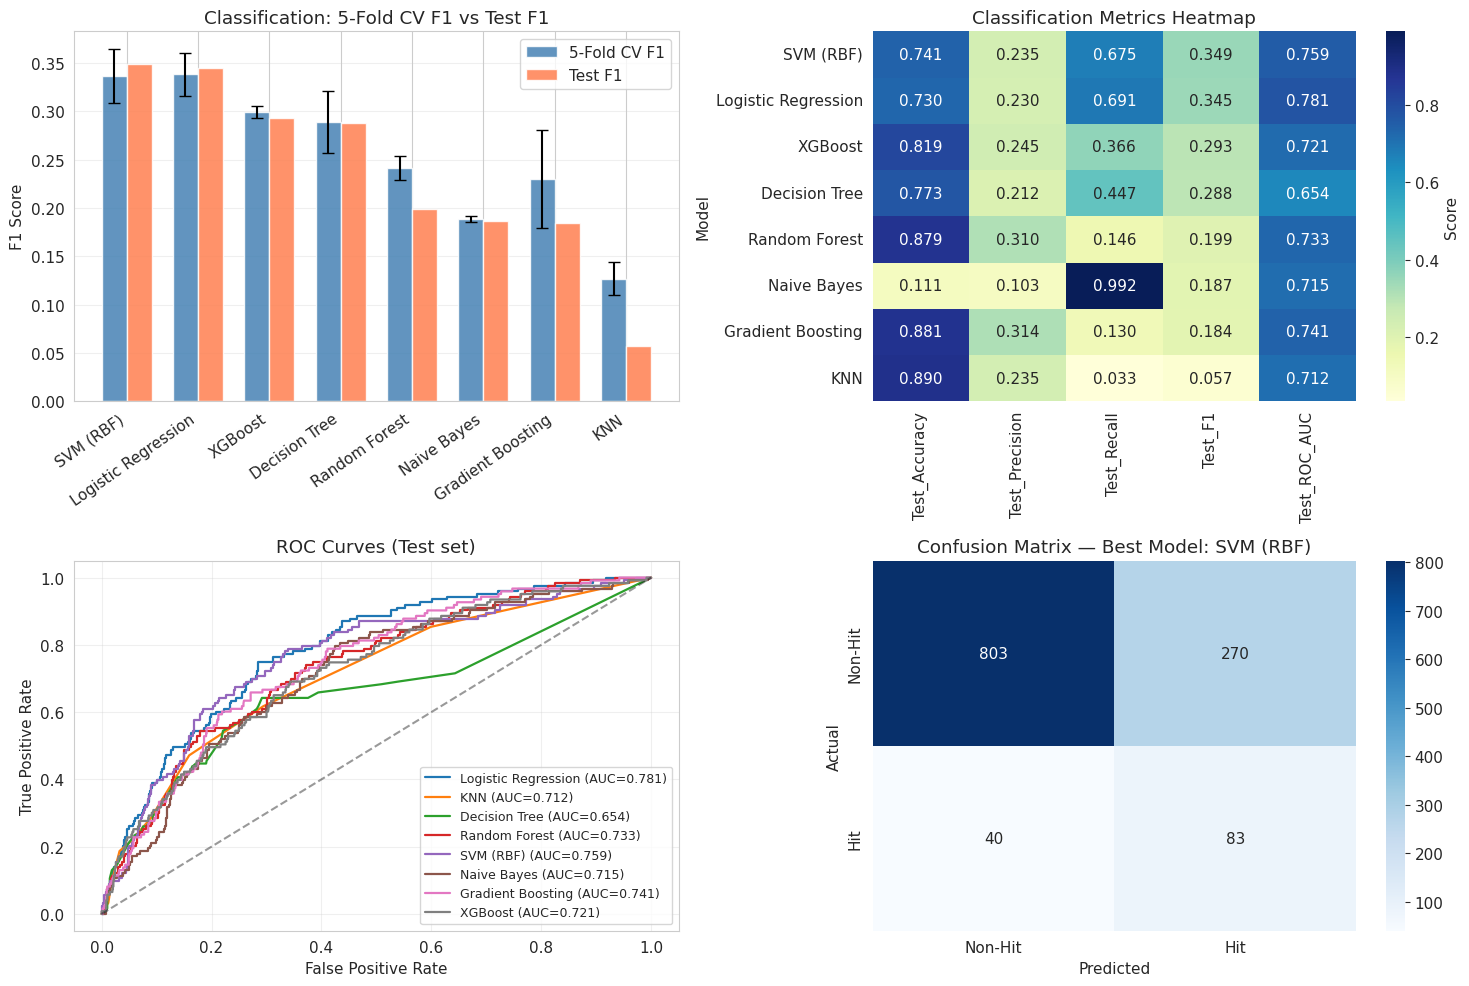


🏆 Best Classification Model: SVM (RBF)
              precision    recall  f1-score   support

     Non-Hit       0.95      0.75      0.84      1073
         Hit       0.24      0.67      0.35       123

    accuracy                           0.74      1196
   macro avg       0.59      0.71      0.59      1196
weighted avg       0.88      0.74      0.79      1196



In [ ]:
# ============================================================
# Classification 결과 시각화
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (1) 5-Fold CV vs Test 비교
ax = axes[0, 0]
x = np.arange(len(clf_df))
w = 0.35
ax.bar(x - w/2, clf_df['CV_F1'], w, label='5-Fold CV F1',
       yerr=clf_df['CV_F1_std'], capsize=4, color='steelblue', alpha=0.85)
ax.bar(x + w/2, clf_df['Test_F1'], w, label='Test F1', color='coral', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(clf_df['Model'], rotation=35, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Classification: 5-Fold CV F1 vs Test F1')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# (2) 지표별 히트맵
ax = axes[0, 1]
metric_cols = ['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_ROC_AUC']
sns.heatmap(
    clf_df.set_index('Model')[metric_cols],
    annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Score'}, ax=ax
)
ax.set_title('Classification Metrics Heatmap')

# (3) ROC Curves
ax = axes[1, 0]
for name, model in clf_trained.items():
    y_proba = model.predict_proba(X_clf_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_clf_te, y_proba)
    auc = roc_auc_score(y_clf_te, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=1.6)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (Test set)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

# (4) Top 모델 Confusion Matrix
ax = axes[1, 1]
best_clf_name = clf_df.iloc[0]['Model']
best_clf = clf_trained[best_clf_name]
y_pred_best = best_clf.predict(X_clf_te)
cm = confusion_matrix(y_clf_te, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Hit', 'Hit'], yticklabels=['Non-Hit', 'Hit'], ax=ax)
ax.set_title(f'Confusion Matrix — Best Model: {best_clf_name}')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('classification_results.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n🏆 Best Classification Model: {best_clf_name}')
print(classification_report(y_clf_te, y_pred_best, target_names=['Non-Hit', 'Hit']))

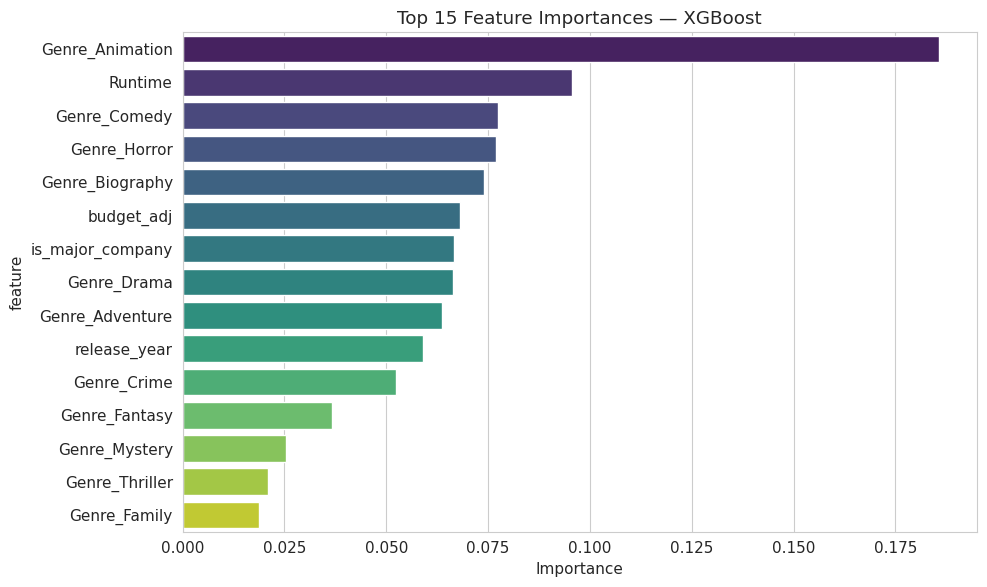

In [ ]:
# Feature Importance — Tree 계열 모델 중 최고 성능 모델 사용
tree_models = ['XGBoost', 'Random Forest', 'Gradient Boosting', 'Decision Tree']
tree_best_name = next((m for m in clf_df['Model'] if m in tree_models), None)

if tree_best_name:
    tree_best = clf_trained[tree_best_name]
    importances = pd.DataFrame({
        'feature': X_clf_tr.columns,
        'importance': tree_best.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=importances, palette='viridis')
    plt.title(f'Top 15 Feature Importances — {tree_best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()

## 3. Regression — Rating 예측

7개 모델 비교: Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, XGBoost

**평가 지표**: RMSE, MAE, R² (R²이 높을수록, RMSE/MAE가 낮을수록 좋음)

In [ ]:
reg_models = {
    'Linear Regression':   LinearRegression(),
    'Ridge':               Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso':               Lasso(alpha=0.01, random_state=RANDOM_STATE, max_iter=10000),
    'Decision Tree':       DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestRegressor(
        n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting':   GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE
    ),
    'XGBoost':             XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
}
print(f'✅ {len(reg_models)}개 Regression 모델 준비')

✅ 7개 Regression 모델 준비


In [ ]:
# ============================================================
# 모델별 학습 & 평가 + 5-Fold Cross Validation
# ============================================================
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
reg_scoring = ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']

reg_results = []
reg_trained = {}

for name, model in reg_models.items():
    print(f'⏳ Training: {name}...', end=' ')

    cv_results = cross_validate(
        model, X_reg_tr, y_reg_tr,
        cv=kf, scoring=reg_scoring, n_jobs=-1
    )

    model.fit(X_reg_tr, y_reg_tr)
    y_pred = model.predict(X_reg_te)

    reg_trained[name] = model

    reg_results.append({
        'Model': name,
        'CV_RMSE':  np.sqrt(-cv_results['test_neg_mean_squared_error'].mean()),
        'CV_MAE':   -cv_results['test_neg_mean_absolute_error'].mean(),
        'CV_R2':    cv_results['test_r2'].mean(),
        'CV_R2_std': cv_results['test_r2'].std(),
        'Test_RMSE': np.sqrt(mean_squared_error(y_reg_te, y_pred)),
        'Test_MAE':  mean_absolute_error(y_reg_te, y_pred),
        'Test_R2':   r2_score(y_reg_te, y_pred),
    })
    print('✅')

reg_df = pd.DataFrame(reg_results).sort_values('Test_R2', ascending=False).reset_index(drop=True)
print('\n' + '='*80)
print('Regression 결과 (Test R² 기준 정렬)')
print('='*80)
reg_df.round(4)

⏳ Training: Linear Regression... ✅
⏳ Training: Ridge... ✅
⏳ Training: Lasso... ✅
⏳ Training: Decision Tree... ✅
⏳ Training: Random Forest... ✅
⏳ Training: Gradient Boosting... ✅
⏳ Training: XGBoost... ✅

Regression 결과 (Test R² 기준 정렬)


,Model,CV_RMSE,CV_MAE,CV_R2,CV_R2_std,Test_RMSE,Test_MAE,Test_R2
0,Gradient Boosting,0.6928,0.5468,0.2445,0.0179,0.6955,0.5499,0.3008
1,Random Forest,0.6965,0.5514,0.2365,0.0223,0.6961,0.5532,0.2996
2,XGBoost,0.7015,0.5543,0.2252,0.0226,0.6978,0.5507,0.2961
3,Ridge,0.6745,0.5374,0.2834,0.0238,0.7061,0.5583,0.2793
4,Linear Regression,0.6747,0.5375,0.2830,0.0240,0.7063,0.5583,0.2789
5,Lasso,0.6822,0.5462,0.2671,0.0194,0.7172,0.5737,0.2564
6,Decision Tree,0.7789,0.6106,0.0451,0.0365,0.7577,0.6004,0.1701


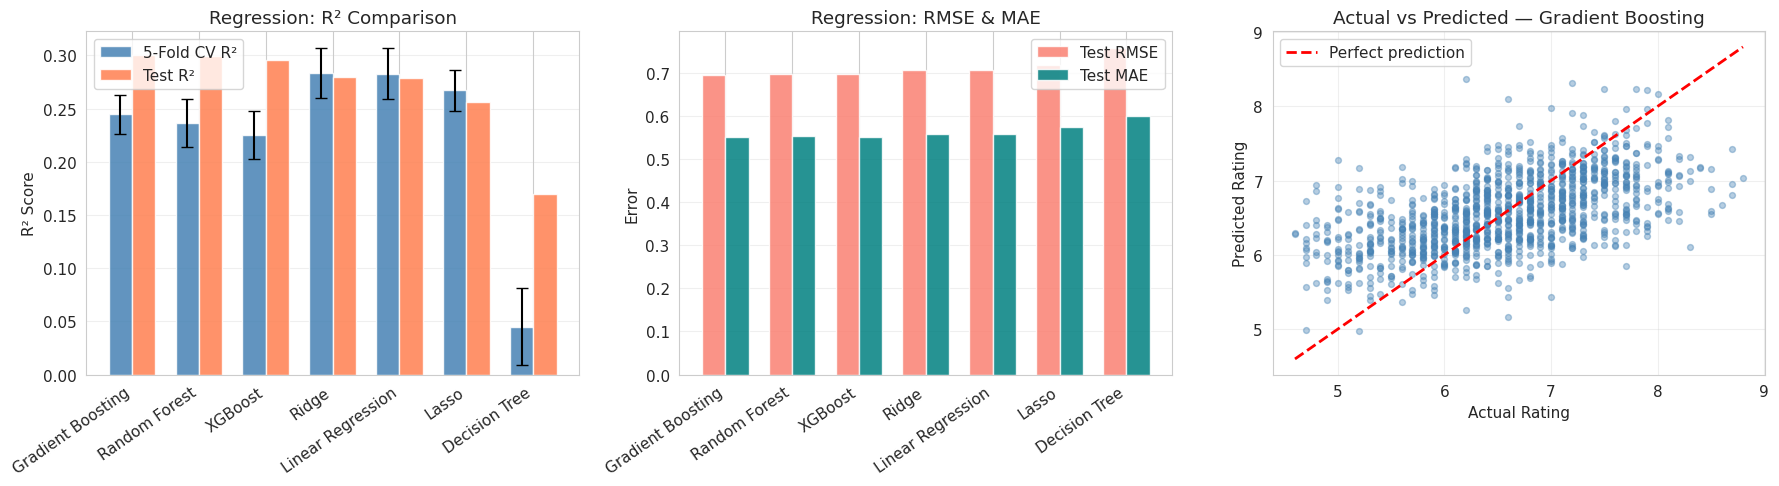


🏆 Best Regression Model: Gradient Boosting
   Test R²:   0.3008
   Test RMSE: 0.6955
   Test MAE:  0.5499


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) R² 비교
ax = axes[0]
x = np.arange(len(reg_df))
w = 0.35
ax.bar(x - w/2, reg_df['CV_R2'], w, label='5-Fold CV R²',
       yerr=reg_df['CV_R2_std'], capsize=4, color='steelblue', alpha=0.85)
ax.bar(x + w/2, reg_df['Test_R2'], w, label='Test R²', color='coral', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(reg_df['Model'], rotation=35, ha='right')
ax.set_ylabel('R² Score')
ax.set_title('Regression: R² Comparison')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# (2) RMSE/MAE 비교
ax = axes[1]
ax.bar(x - w/2, reg_df['Test_RMSE'], w, label='Test RMSE', color='salmon', alpha=0.85)
ax.bar(x + w/2, reg_df['Test_MAE'], w, label='Test MAE', color='teal', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(reg_df['Model'], rotation=35, ha='right')
ax.set_ylabel('Error')
ax.set_title('Regression: RMSE & MAE')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# (3) Best 모델 Actual vs Predicted
ax = axes[2]
best_reg_name = reg_df.iloc[0]['Model']
best_reg = reg_trained[best_reg_name]
y_pred_best = best_reg.predict(X_reg_te)
ax.scatter(y_reg_te, y_pred_best, alpha=0.4, s=18, color='steelblue')
ax.plot([y_reg_te.min(), y_reg_te.max()],
        [y_reg_te.min(), y_reg_te.max()], 'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('Actual Rating'); ax.set_ylabel('Predicted Rating')
ax.set_title(f'Actual vs Predicted — {best_reg_name}')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n🏆 Best Regression Model: {best_reg_name}')
print(f'   Test R²:   {reg_df.iloc[0]["Test_R2"]:.4f}')
print(f'   Test RMSE: {reg_df.iloc[0]["Test_RMSE"]:.4f}')
print(f'   Test MAE:  {reg_df.iloc[0]["Test_MAE"]:.4f}')

## 4. Best-5 자동 탐색 함수 (오픈소스 기여)

**목표**: 스케일러 × 모델 × 하이퍼파라미터의 모든 조합을 K-fold CV로 평가하고 Top-5 반환

Pandas/Scikit-learn 스타일 docstring으로 작성하여 GitHub에 공개

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from itertools import product
from sklearn.base import clone
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score

def find_best_combinations(
    X, y,
    scalers,
    models_with_params,
    task='classification',
    cv=5,
    scoring=None,
    top_k=5,
    numeric_cols=None,
    random_state=42,
    verbose=True,
):

    """Find the top-k (scaler, model, hyperparameter) combinations via K-fold CV.

    Iterates over every combination of provided scalers, models, and hyperparameter
    grids, then evaluates each combination using K-fold cross validation on the
    given dataset.

    Parameters
    ----------
    X : pandas.DataFrame
        Feature matrix.
    y : pandas.Series or array-like
        Target variable. Binary or multiclass for classification, continuous for
        regression.
    scalers : dict of {str: object}
        Mapping from scaler name to a scikit-learn scaler instance. Pass
        ``{'None': None}`` to skip scaling.
    models_with_params : dict of {str: (estimator, param_grid)}
        Mapping from model name to a tuple ``(estimator, param_grid)``, where
        ``param_grid`` is a dict like ``{'param_name': [values, ...]}``.
    task : {'classification', 'regression'}, default='classification'
        Type of task. Determines the CV strategy (StratifiedKFold vs KFold) and
        the default scoring metric.
    cv : int, default=5
        Number of cross validation folds.
    scoring : str, optional
        Scikit-learn scoring string. Defaults to ``'f1'`` for classification and
        ``'r2'`` for regression.
    top_k : int, default=5
        Number of best combinations to return.
    numeric_cols : list of str, optional
        Subset of columns in X to which the scaler should be applied. If None,
        the scaler is applied to all columns.
    random_state : int, default=42
        Random seed for the cross validation splitter.
    verbose : bool, default=True
        If True, prints progress for each combination.

    Returns
    -------
    results : pandas.DataFrame
        DataFrame with columns ``['rank', 'scaler', 'model', 'params',
        'mean_score', 'std_score', 'fit_time']`` sorted by ``mean_score``
        descending. Only the top-k rows are returned.

    Examples
    --------
    >>> from sklearn.preprocessing import StandardScaler, MinMaxScaler
    >>> from sklearn.linear_model import LogisticRegression
    >>> from sklearn.ensemble import RandomForestClassifier
    >>> scalers = {'Standard': StandardScaler(), 'MinMax': MinMaxScaler()}
    >>> models = {
    ...     'LogReg': (LogisticRegression(max_iter=1000), {'C': [0.1, 1.0]}),
    ...     'RF':     (RandomForestClassifier(), {'n_estimators': [100, 200]}),
    ... }
    >>> top5 = find_best_combinations(X, y, scalers, models, task='classification')
    """

    # Default scoring
    if scoring is None:
        scoring = 'f1' if task == 'classification' else 'r2'

    # CV splitter
    if task == 'classification':
        cv_splitter = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    elif task == 'regression':
        cv_splitter = KFold(n_splits=cv, shuffle=True, random_state=random_state)
    else:
        raise ValueError("task must be 'classification' or 'regression'")

    results = []

    # 총 조합 수 계산
    total = sum(
        len(scalers) * np.prod([len(v) for v in pg.values()] or [1])
        for _, pg in models_with_params.values()
    )
    if verbose:
        print(f'Total combinations: {int(total)}')

    count = 0
    for model_name, (base_estimator, param_grid) in models_with_params.items():
        # param_grid를 모든 조합으로 펼침
        if param_grid:
            param_keys = list(param_grid.keys())
            param_combos = [dict(zip(param_keys, vals)) for vals in product(*param_grid.values())]
        else:
            param_combos = [{}]

        for scaler_name, scaler in scalers.items():
            for params in param_combos:
                count += 1

                # 1. 파라미터가 적용된 모델 셋업
                estimator = clone(base_estimator).set_params(**params)

                # 2. Pipeline 구성 (핵심 포인트: 데이터 누수 원천 차단)
                steps = []
                if scaler is not None:
                    if numeric_cols:
                        # 지정된 컬럼만 스케일링하고 나머지는 그대로 통과시킴
                        preprocessor = ColumnTransformer(
                            transformers=[('num', clone(scaler), numeric_cols)],
                            remainder='passthrough'
                        )
                        steps.append(('preprocessor', preprocessor))
                    else:
                        steps.append(('scaler', clone(scaler)))

                steps.append(('model', estimator))
                pipe = Pipeline(steps)

                t0 = time.time()
                try:
                    # 3. 스케일링이 안 된 순수한 X 원본을 넣음 (Pipeline이 fold별로 알아서 분리 후 스케일링함)
                    scores = cross_val_score(
                        pipe, X, y,
                        cv=cv_splitter, scoring=scoring, n_jobs=-1
                    )
                    mean_score, std_score = scores.mean(), scores.std()
                except Exception as e:
                    mean_score, std_score = np.nan, np.nan
                    if verbose:
                        print(f'  [{count}/{int(total)}] ❌ {model_name} | {scaler_name} | {params} → {e}')
                    continue
                fit_time = time.time() - t0

                results.append({
                    'scaler': scaler_name,
                    'model':  model_name,
                    'params': params,
                    'mean_score': mean_score,
                    'std_score':  std_score,
                    'fit_time':   fit_time,
                })
                if verbose:
                    print(f'  [{count}/{int(total)}] {model_name:20s} | {scaler_name:10s} | '
                          f'score={mean_score:.4f} ±{std_score:.4f} | {fit_time:.1f}s')

    result_df = pd.DataFrame(results).sort_values('mean_score', ascending=False)
    result_df.insert(0, 'rank', range(1, len(result_df) + 1))
    return result_df.head(top_k).reset_index(drop=True)

## 5. Classification - Best-5 자동 탐색 함수

In [ ]:
# ============================================================
# 실행: Classification Top-5 조합 찾기
# ============================================================
print('🔍 Classification Best-5 탐색 시작\n')

# 스케일러 후보 (3개)
clf_scalers = {
    'Standard': StandardScaler(),
    'MinMax':   MinMaxScaler(),
    'Robust':   RobustScaler(),
}

# 모델 + 하이퍼파라미터 그리드
clf_search_space = {
    'LogisticRegression': (
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
        {'C': [0.1, 1.0, 10.0]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [5, 15, 25]}
    ),
    'RandomForest': (
        RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [10, 20]}
    ),
    'GradientBoosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]}
    ),
    'XGBoost': (
        XGBClassifier(
            eval_metric='logloss', use_label_encoder=False,
            scale_pos_weight=neg_pos_ratio,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        {'n_estimators': [100, 200], 'max_depth': [4, 8]}
    ),
}

# 전체 데이터 X_clf 사용 (Best-5 함수가 내부에서 CV)
top5_clf = find_best_combinations(
    X_clf_tr, y_clf_tr,
    scalers=clf_scalers,
    models_with_params=clf_search_space,
    task='classification',
    cv=5,
    scoring='f1',
    top_k=5,
    numeric_cols=num_cols_clf,
    verbose=True,
)

print('\n' + '='*90)
print('🏆 Classification Top-5 (5-Fold CV F1 기준)')
print('='*90)
top5_clf.round(4)

🔍 Classification Best-5 탐색 시작

Total combinations: 54
  [1/54] LogisticRegression   | Standard   | score=0.3356 ±0.0173 | 0.2s
  [2/54] LogisticRegression   | Standard   | score=0.3381 ±0.0221 | 0.2s
  [3/54] LogisticRegression   | Standard   | score=0.3354 ±0.0207 | 0.3s
  [4/54] LogisticRegression   | MinMax     | score=0.3108 ±0.0106 | 0.2s
  [5/54] LogisticRegression   | MinMax     | score=0.3317 ±0.0189 | 0.2s
  [6/54] LogisticRegression   | MinMax     | score=0.3359 ±0.0201 | 0.2s
  [7/54] LogisticRegression   | Robust     | score=0.3354 ±0.0181 | 0.2s
  [8/54] LogisticRegression   | Robust     | score=0.3381 ±0.0222 | 0.2s
  [9/54] LogisticRegression   | Robust     | score=0.3356 ±0.0204 | 0.2s
  [10/54] KNN                  | Standard   | score=0.2217 ±0.0478 | 0.2s
  [11/54] KNN                  | Standard   | score=0.1265 ±0.0170 | 0.3s
  [12/54] KNN                  | Standard   | score=0.1273 ±0.0470 | 0.2s
  [13/54] KNN                  | MinMax     | score=0.1744 ±0.0491 

,rank,scaler,model,params,mean_score,std_score,fit_time
0,1,MinMax,RandomForest,"{'n_estimators': 200, 'max_depth': 10}",0.3428,0.0237,3.6494
1,2,Robust,RandomForest,"{'n_estimators': 200, 'max_depth': 10}",0.3390,0.0202,3.6879
2,3,Robust,LogisticRegression,{'C': 1.0},0.3381,0.0222,0.1905
3,4,Standard,LogisticRegression,{'C': 1.0},0.3381,0.0221,0.2018
4,5,Standard,RandomForest,"{'n_estimators': 200, 'max_depth': 10}",0.3380,0.0157,3.6365


## 6. Classification - Best-5 자동 탐색 함수

In [ ]:
# ============================================================
# 실행: Regression Top-5 조합 찾기
# ============================================================
print('🔍 Regression Best-5 탐색 시작\n')

reg_scalers = {
    'Standard': StandardScaler(),
    'MinMax':   MinMaxScaler(),
    'Robust':   RobustScaler(),
}

reg_search_space = {
    'Ridge': (
        Ridge(random_state=RANDOM_STATE),
        {'alpha': [0.1, 1.0, 10.0]}
    ),
    'Lasso': (
        Lasso(random_state=RANDOM_STATE, max_iter=10000),
        {'alpha': [0.001, 0.01, 0.1]}
    ),
    'RandomForest': (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [10, 20]}
    ),
    'GradientBoosting': (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]}
    ),
    'XGBoost': (
        XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [4, 8]}
    ),
}

top5_reg = find_best_combinations(
    X_reg_tr, y_reg_tr,
    scalers=reg_scalers,
    models_with_params=reg_search_space,
    task='regression',
    cv=5,
    scoring='r2',
    top_k=5,
    numeric_cols=num_cols_reg,
    verbose=True,
)

print('\n' + '='*90)
print('🏆 Regression Top-5 (5-Fold CV R² 기준)')
print('='*90)
top5_reg.round(4)

🔍 Regression Best-5 탐색 시작

Total combinations: 54
  [1/54] Ridge                | Standard   | score=0.2831 ±0.0240 | 0.1s
  [2/54] Ridge                | Standard   | score=0.2834 ±0.0238 | 0.1s
  [3/54] Ridge                | Standard   | score=0.2840 ±0.0232 | 0.1s
  [4/54] Ridge                | MinMax     | score=0.2831 ±0.0238 | 0.1s
  [5/54] Ridge                | MinMax     | score=0.2833 ±0.0227 | 0.1s
  [6/54] Ridge                | MinMax     | score=0.2739 ±0.0166 | 0.1s
  [7/54] Ridge                | Robust     | score=0.2831 ±0.0240 | 0.1s
  [8/54] Ridge                | Robust     | score=0.2834 ±0.0238 | 0.1s
  [9/54] Ridge                | Robust     | score=0.2840 ±0.0231 | 0.1s
  [10/54] Lasso                | Standard   | score=0.2839 ±0.0235 | 0.1s
  [11/54] Lasso                | Standard   | score=0.2671 ±0.0194 | 0.1s
  [12/54] Lasso                | Standard   | score=0.1770 ±0.0123 | 0.1s
  [13/54] Lasso                | MinMax     | score=0.2836 ±0.0222 | 0.

,rank,scaler,model,params,mean_score,std_score,fit_time
0,1,MinMax,GradientBoosting,"{'n_estimators': 200, 'learning_rate': 0.05}",0.2937,0.0182,3.4677
1,2,Robust,GradientBoosting,"{'n_estimators': 200, 'learning_rate': 0.05}",0.2936,0.0180,3.4938
2,3,Standard,GradientBoosting,"{'n_estimators': 200, 'learning_rate': 0.05}",0.2935,0.0180,3.6010
3,4,MinMax,GradientBoosting,"{'n_estimators': 100, 'learning_rate': 0.1}",0.2906,0.0193,1.8157
4,5,Robust,GradientBoosting,"{'n_estimators': 100, 'learning_rate': 0.1}",0.2906,0.0192,1.7819


## 7. 최종 결과 요약 및 저장

📊 Grid Search 결과를 바탕으로 1등 모델 최종 분석...


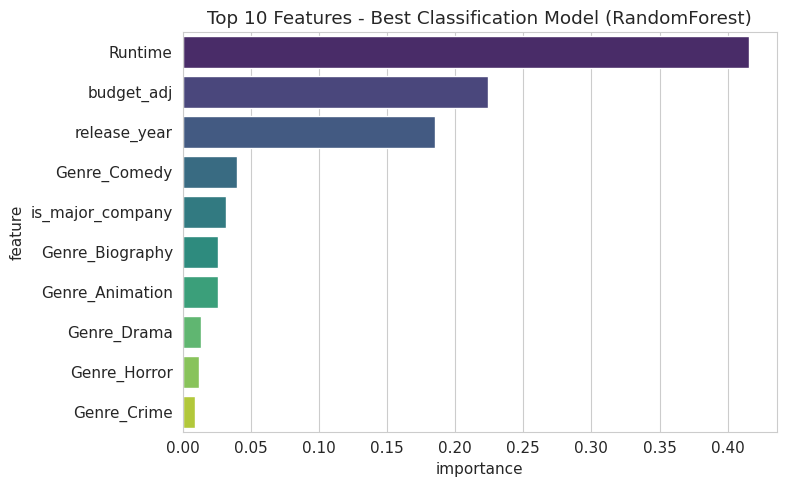

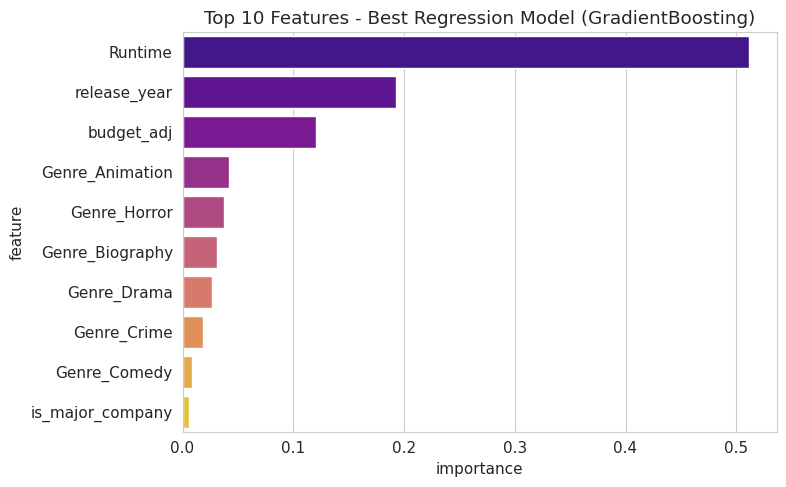


💾 4개의 CSV 및 2개의 중요도 PNG 파일 저장 완료!

📊 최종 요약

[Classification 기본 모델] 🏆 Best: SVM (RBF)
  Test F1:      0.3487
  Test ROC-AUC: 0.7592
  5-Fold CV F1: 0.3364 ±0.0280

[Regression 기본 모델] 🏆 Best: Gradient Boosting
  Test R²:    0.3008
  Test RMSE:  0.6955
  Test MAE:   0.5499

[오픈소스 함수 튜닝 최적화 결과]
  - Classification (Tuned): MinMax + RandomForest + {'n_estimators': 200, 'max_depth': 10}
    → CV F1 = 0.3428  |  🎯 최종 Test F1 = 0.3243
  - Regression (Tuned): MinMax + GradientBoosting + {'n_estimators': 200, 'learning_rate': 0.05}
    → CV R² = 0.2937  |  🎯 최종 Test R² = 0.3270


In [ ]:
# ============================================================
# 7. 최우수 모델 최종 Test 평가 및 Feature Importance 추출
# ============================================================
print("📊 Grid Search 결과를 바탕으로 1등 모델 최종 분석...")

# ------------------------------------------------------------
# [1] Classification (분류) 1등 모델 최종 평가 및 시각화
# ------------------------------------------------------------
best_clf_row = top5_clf.iloc[0]
best_clf_scaler = clf_scalers.get(best_clf_row['scaler'])
best_clf_model_name = best_clf_row['model']

X_clf_tr_final = X_clf_tr.copy()
X_clf_te_final = X_clf_te.copy()
if best_clf_scaler is not None:
    X_clf_tr_final[num_cols_clf] = best_clf_scaler.fit_transform(X_clf_tr_final[num_cols_clf])
    X_clf_te_final[num_cols_clf] = best_clf_scaler.transform(X_clf_te_final[num_cols_clf])

base_clf_estimator = clf_search_space[best_clf_model_name][0]
final_clf_model = clone(base_clf_estimator).set_params(**best_clf_row['params'])

final_clf_model.fit(X_clf_tr_final, y_clf_tr)
clf_test_pred = final_clf_model.predict(X_clf_te_final)
final_clf_test_score = f1_score(y_clf_te, clf_test_pred)

if hasattr(final_clf_model, 'feature_importances_'):
    importances_clf = pd.DataFrame({'feature': X_clf_tr.columns, 'importance': final_clf_model.feature_importances_}).sort_values('importance', ascending=False).head(10)
    plt.figure(figsize=(8, 5))
    sns.barplot(x='importance', y='feature', data=importances_clf, palette='viridis')
    plt.title(f'Top 10 Features - Best Classification Model ({best_clf_model_name})')
    plt.tight_layout()
    plt.savefig('feature_importance_clf.png')
    plt.show()

# ------------------------------------------------------------
# [2] Regression (회귀) 1등 모델 최종 평가 및 시각화
# ------------------------------------------------------------
best_reg_row = top5_reg.iloc[0]
best_reg_scaler = reg_scalers.get(best_reg_row['scaler'])
best_reg_model_name = best_reg_row['model']

X_reg_tr_final = X_reg_tr.copy()
X_reg_te_final = X_reg_te.copy()
if best_reg_scaler is not None:
    X_reg_tr_final[num_cols_reg] = best_reg_scaler.fit_transform(X_reg_tr_final[num_cols_reg])
    X_reg_te_final[num_cols_reg] = best_reg_scaler.transform(X_reg_te_final[num_cols_reg])

base_reg_estimator = reg_search_space[best_reg_model_name][0]
final_reg_model = clone(base_reg_estimator).set_params(**best_reg_row['params'])

final_reg_model.fit(X_reg_tr_final, y_reg_tr)
reg_test_pred = final_reg_model.predict(X_reg_te_final)
final_reg_test_score = r2_score(y_reg_te, reg_test_pred)

if hasattr(final_reg_model, 'feature_importances_'):
    importances_reg = pd.DataFrame({'feature': X_reg_tr.columns, 'importance': final_reg_model.feature_importances_}).sort_values('importance', ascending=False).head(10)
    plt.figure(figsize=(8, 5))
    sns.barplot(x='importance', y='feature', data=importances_reg, palette='plasma')
    plt.title(f'Top 10 Features - Best Regression Model ({best_reg_model_name})')
    plt.tight_layout()
    plt.savefig('feature_importance_reg.png')
    plt.show()

# ============================================================
# 8. CSV 최종 저장
# ============================================================
clf_df.to_csv('results_classification.csv', index=False)
reg_df.to_csv('results_regression.csv', index=False)
top5_clf.to_csv('top5_classification.csv', index=False)
top5_reg.to_csv('top5_regression.csv', index=False)

print("\n💾 4개의 CSV 및 2개의 중요도 PNG 파일 저장 완료!")

# ============================================================
# 9. 최종 요약 출력
# ============================================================
print('\n' + '='*70)
print('📊 최종 요약')
print('='*70)
print(f'\n[Classification 기본 모델] 🏆 Best: {clf_df.iloc[0]["Model"]}')
print(f'  Test F1:      {clf_df.iloc[0]["Test_F1"]:.4f}')
print(f'  Test ROC-AUC: {clf_df.iloc[0]["Test_ROC_AUC"]:.4f}')
print(f'  5-Fold CV F1: {clf_df.iloc[0]["CV_F1"]:.4f} ±{clf_df.iloc[0]["CV_F1_std"]:.4f}')

print(f'\n[Regression 기본 모델] 🏆 Best: {reg_df.iloc[0]["Model"]}')
print(f'  Test R²:    {reg_df.iloc[0]["Test_R2"]:.4f}')
print(f'  Test RMSE:  {reg_df.iloc[0]["Test_RMSE"]:.4f}')
print(f'  Test MAE:   {reg_df.iloc[0]["Test_MAE"]:.4f}')

print(f'\n[오픈소스 함수 튜닝 최적화 결과]')
print(f'  - Classification (Tuned): {best_clf_row["scaler"]} + {best_clf_model_name} + {best_clf_row["params"]}')
print(f'    → CV F1 = {best_clf_row["mean_score"]:.4f}  |  🎯 최종 Test F1 = {final_clf_test_score:.4f}')
print(f'  - Regression (Tuned): {best_reg_row["scaler"]} + {best_reg_model_name} + {best_reg_row["params"]}')
print(f'    → CV R² = {best_reg_row["mean_score"]:.4f}  |  🎯 최종 Test R² = {final_reg_test_score:.4f}')